In [97]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, RocCurveDisplay
)

# Global seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})

print("✓ All imports successful.")



✓ All imports successful.


In [98]:
df = pd.read_csv('data_cleaned(1).csv')  # adjust path if needed

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

Shape: (100000, 16)

Columns: ['college_tier', 'placement_status', 'salary_package_lpa', 'salary_available', 'tech_skill', 'soft_skill', 'practical_skill', 'cgpa_scaled', 'backlogs_scaled', 'academic_points', 'branch_CSE', 'branch_Chemical', 'branch_ECE', 'branch_EE', 'branch_IT', 'branch_ME']


,college_tier,placement_status,salary_package_lpa,salary_available,tech_skill,soft_skill,practical_skill,cgpa_scaled,backlogs_scaled,academic_points,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME
0,3,1,14.75,1,0.524977,0.316667,0.783333,0.450000,0.000000,0.615000,0,0,1,0,0,0
1,2,0,NaN,0,0.454259,0.405556,0.200000,0.283333,0.000000,0.498333,0,1,0,0,0,0
2,2,1,19.06,1,0.559051,0.355556,0.566667,0.531667,0.000000,0.672167,0,0,0,1,0,0
3,2,0,NaN,0,0.430833,0.222222,0.283333,0.413333,0.000000,0.589333,0,0,0,0,0,0
4,2,1,13.42,1,0.336759,0.350000,0.433333,0.451667,0.333333,0.516167,1,0,0,0,0,0


In [99]:
# Drop salary_package_lpa and salary_available — post-placement leakage
df.drop(columns=["salary_package_lpa", "salary_available"], errors="ignore", inplace=True)
print("✓  Dropped 'salary_package_lpa' and 'salary_available'")

# Fix any remaining NaN
for col in df.columns:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
        print(f"   Fixed NaN in '{col}'")

print(f"\n✓  Missing values remaining : {df.isnull().sum().sum()}")

X = df.drop(columns=["placement_status"])
y = df["placement_status"]
print(f"\n✓  Features ({X.shape[1]}) : {X.columns.tolist()}")
print(f"   Target : placement_status  (0 = Not Placed, 1 = Placed)")

df

✓  Dropped 'salary_package_lpa' and 'salary_available'

✓  Missing values remaining : 0

✓  Features (13) : ['college_tier', 'tech_skill', 'soft_skill', 'practical_skill', 'cgpa_scaled', 'backlogs_scaled', 'academic_points', 'branch_CSE', 'branch_Chemical', 'branch_ECE', 'branch_EE', 'branch_IT', 'branch_ME']
   Target : placement_status  (0 = Not Placed, 1 = Placed)


,college_tier,placement_status,tech_skill,soft_skill,practical_skill,cgpa_scaled,backlogs_scaled,academic_points,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME
0,3,1,0.524977,0.316667,0.783333,0.450000,0.000000,0.615000,0,0,1,0,0,0
1,2,0,0.454259,0.405556,0.200000,0.283333,0.000000,0.498333,0,1,0,0,0,0
2,2,1,0.559051,0.355556,0.566667,0.531667,0.000000,0.672167,0,0,0,1,0,0
3,2,0,0.430833,0.222222,0.283333,0.413333,0.000000,0.589333,0,0,0,0,0,0
4,2,1,0.336759,0.350000,0.433333,0.451667,0.333333,0.516167,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,3,0,0.517454,0.683333,0.316667,0.346667,0.000000,0.542667,0,0,0,0,1,0
99996,3,1,0.518403,0.366667,0.308333,0.576667,0.000000,0.703667,0,0,0,0,1,0
99997,2,1,0.482014,0.616667,0.225000,0.656667,0.000000,0.759667,0,0,0,1,0,0
99998,3,1,0.487454,0.427778,0.283333,0.438333,0.000000,0.606833,0,0,0,0,0,1


In [100]:
df['placement_status'].value_counts()

placement_status
1    68475
0    31525
Name: count, dtype: int64

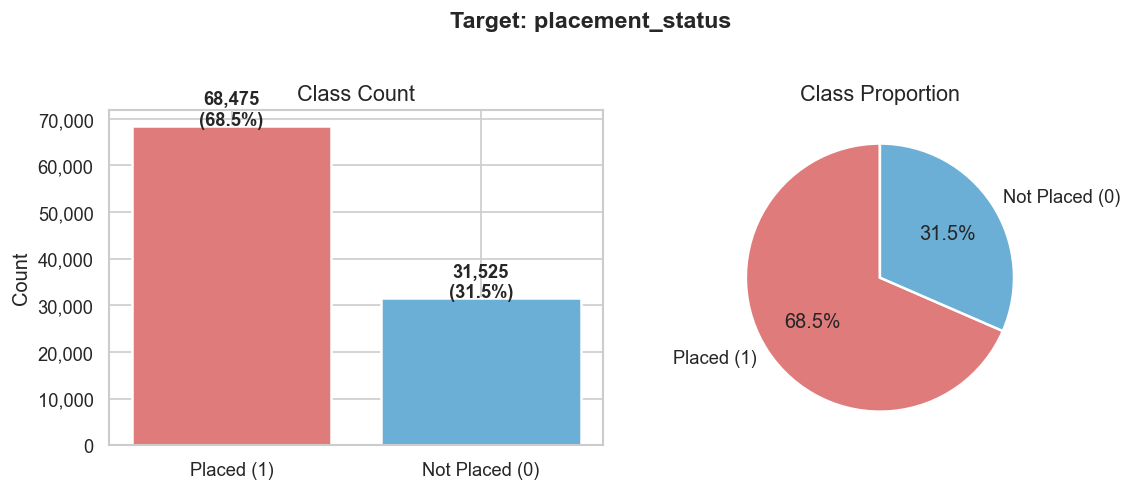

In [101]:
vc     = df["placement_status"].value_counts()
labels = ["Placed (1)","Not Placed (0)"]
colors = ["#e07b7b", "#6baed6"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
axes[0].bar(labels, vc.values, color=colors, edgecolor="white", linewidth=1.5)
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Class Count")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Pie chart
axes[1].pie(vc.values, labels=labels, autopct="%1.1f%%",
            colors=colors, startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Class Proportion")

plt.suptitle("Target: placement_status", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

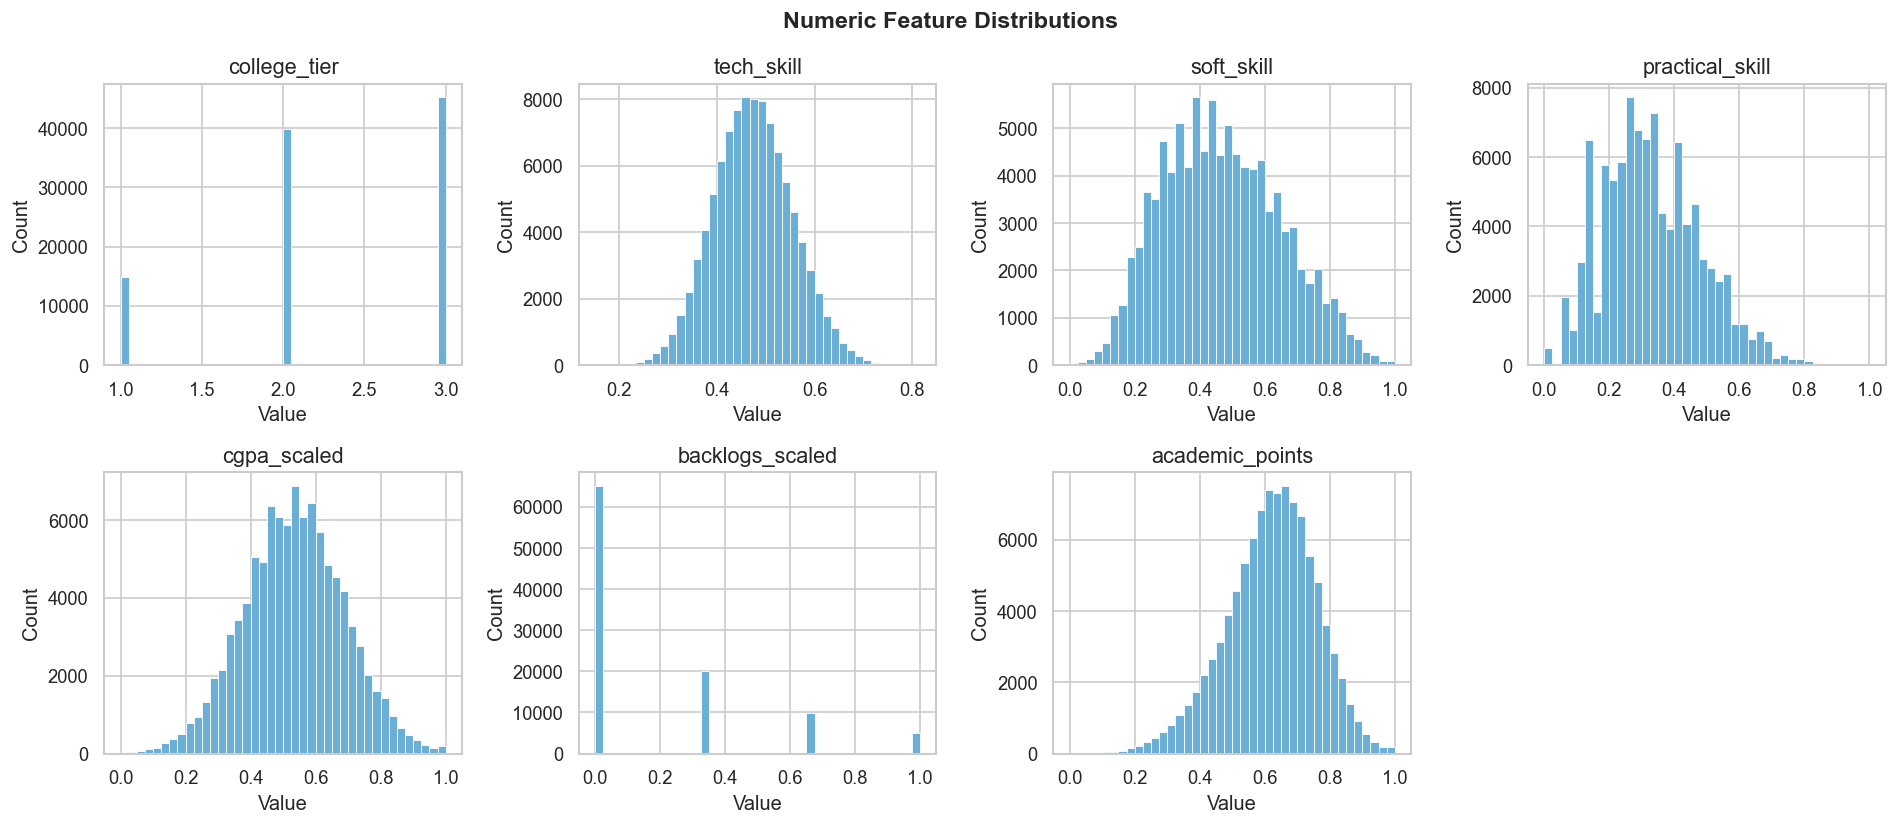

In [102]:
numeric_cols = ["college_tier", "tech_skill", "soft_skill", "practical_skill",
                "cgpa_scaled", "backlogs_scaled", "academic_points"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color="#6baed6", edgecolor="white", linewidth=0.5)
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

axes[-1].set_visible(False)  # hide empty 8th subplot
plt.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

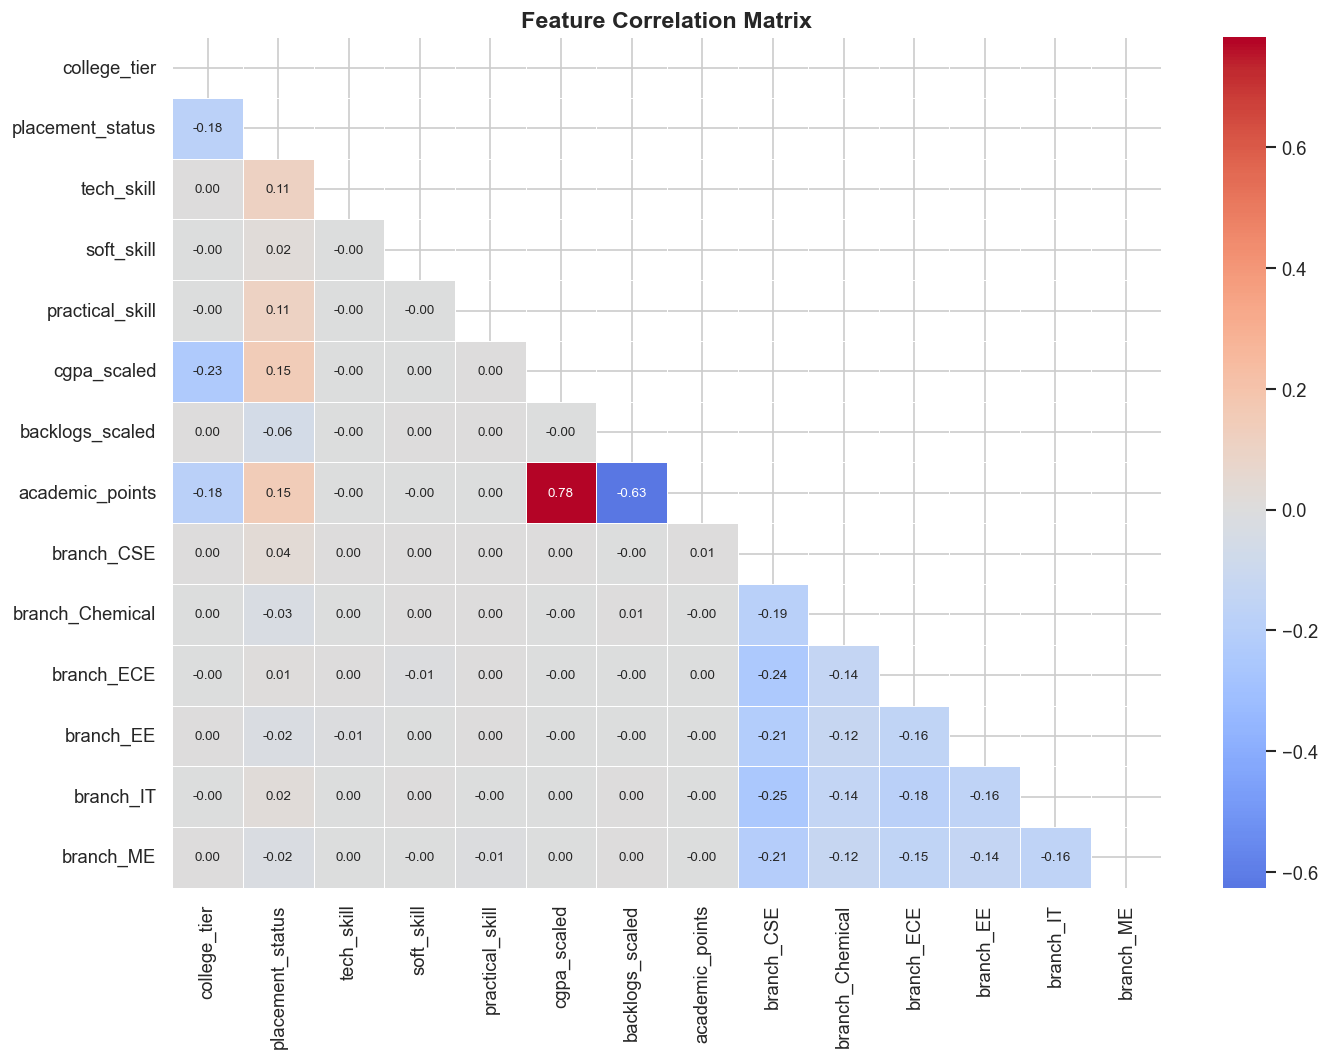

In [103]:
fig, ax = plt.subplots(figsize=(12, 9))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})

ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [104]:
# 80% train | 20% test, stratified to preserve 68.5/31.5 class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
gb = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

print("✓ All models retrained on 13 clean features")

✓ All models retrained on 13 clean features


In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# ── Model 1: Logistic Regression ──────────────────────────────────
print("[1] Training Logistic Regression ...")
lr = LogisticRegression(
    C            = 0.1,      # relaxed from 0.1 — gives model more freedom
    max_iter     = 500,
    solver       = "lbfgs",
    random_state = RANDOM_STATE
)
lr.fit(X_train, y_train)
print(f"    Done — Accuracy: {lr.score(X_test, y_test)*100:.2f}%")

# ── Model 2: Random Forest ────────────────────────────────────────
print("\n[2] Training Random Forest ...")
rf = RandomForestClassifier(
    n_estimators     = 500,   # more trees = more stable
    max_depth        = 10,     # deeper trees = learns more patterns
    min_samples_leaf = 10,    # reduced from 20
    max_features     = "sqrt",
    random_state     = RANDOM_STATE,
    n_jobs           = -1
)
rf.fit(X_train, y_train)
print(f"    Done — Accuracy: {rf.score(X_test, y_test)*100:.2f}%")

# ── Model 3: Gradient Boosting ────────────────────────────────────
print("\n[3] Training Gradient Boosting ...")
gb = GradientBoostingClassifier(
    n_estimators  = 200,     # more rounds
    max_depth     = 8,       # deeper than before
    learning_rate = 0.08,    # slower but more precise
    subsample     = 0.8,
    min_samples_leaf = 10,
    random_state  = RANDOM_STATE
)
gb.fit(X_train, y_train)
print(f"    Done — Accuracy: {gb.score(X_test, y_test)*100:.2f}%")

[1] Training Logistic Regression ...
    Done — Accuracy: 69.47%

[2] Training Random Forest ...
    Done — Accuracy: 69.13%

[3] Training Gradient Boosting ...
    Done — Accuracy: 68.91%


In [106]:
# ── Bonus: Try XGBoost if available ──────────────────────────────
try:
    from xgboost import XGBClassifier

    print("[4] Training XGBoost ...")
    xgb = XGBClassifier(
        n_estimators     = 200,
        max_depth        = 9,
        learning_rate    = 0.08,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        use_label_encoder= False,
        eval_metric      = "logloss",
        random_state     = RANDOM_STATE
    )
    xgb.fit(X_train, y_train)
    print(f"    Done — Accuracy: {xgb.score(X_test, y_test)*100:.2f}%")

    # Add to models dict if already defined
    

except ImportError:
    print("XGBoost not installed — run:  pip install xgboost")

[4] Training XGBoost ...
    Done — Accuracy: 68.51%


In [107]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Full evaluation report for a trained classifier.
    Returns test accuracy (float).
    """
    y_pred    = model.predict(X_te)
    y_prob    = model.predict_proba(X_te)[:, 1]
    acc       = accuracy_score(y_te, y_pred)
    roc_auc   = roc_auc_score(y_te, y_prob)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=5, scoring="accuracy", n_jobs=-1)

    status = "✅  IN TARGET RANGE" if 0.73 <= acc <= 0.78 else "⚠️  OUT OF TARGET RANGE"

    print(f"{'─'*55}")
    print(f"  Model          : {name}")
    print(f"  Test Accuracy  : {acc*100:.2f}%   {status}")
    print(f"  ROC-AUC        : {roc_auc:.4f}")
    print(f"  CV Acc (5-fold): {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred,
                                target_names=["Not Placed (0)", "Placed (1)"],
                                digits=3, zero_division=0))
    cm = confusion_matrix(y_te, y_pred)
    print("  Confusion Matrix:")
    print(f"                        Pred Not Placed   Pred Placed")
    print(f"  Actual Not Placed       TN={cm[0,0]:>6,}        FP={cm[0,1]:>6,}")
    print(f"  Actual Placed           FN={cm[1,0]:>6,}        TP={cm[1,1]:>6,}")
    print()
    return acc

print("✓ evaluate_model() ready.")

✓ evaluate_model() ready.


In [108]:
results = {}
results["Logistic Regression"] = evaluate_model(
    "Logistic Regression", lr, X_train, y_train, X_test, y_test)
results["Random Forest"]        = evaluate_model(
    "Random Forest",        rf, X_train, y_train, X_test, y_test)
results["Gradient Boosting"]    = evaluate_model(
    "Gradient Boosting",    gb, X_train, y_train, X_test, y_test)

───────────────────────────────────────────────────────
  Model          : Logistic Regression
  Test Accuracy  : 69.47%   ⚠️  OUT OF TARGET RANGE
  ROC-AUC        : 0.6720
  CV Acc (5-fold): 69.44% ± 0.24%

  Classification Report:
                precision    recall  f1-score   support

Not Placed (0)      0.554     0.162     0.250      6305
    Placed (1)      0.709     0.940     0.808     13695

      accuracy                          0.695     20000
     macro avg      0.631     0.551     0.529     20000
  weighted avg      0.660     0.695     0.632     20000

  Confusion Matrix:
                        Pred Not Placed   Pred Placed
  Actual Not Placed       TN= 1,019        FP= 5,286
  Actual Placed           FN=   821        TP=12,874

───────────────────────────────────────────────────────
  Model          : Random Forest
  Test Accuracy  : 69.13%   ⚠️  OUT OF TARGET RANGE
  ROC-AUC        : 0.6686
  CV Acc (5-fold): 69.25% ± 0.28%

  Classification Report:
                prec

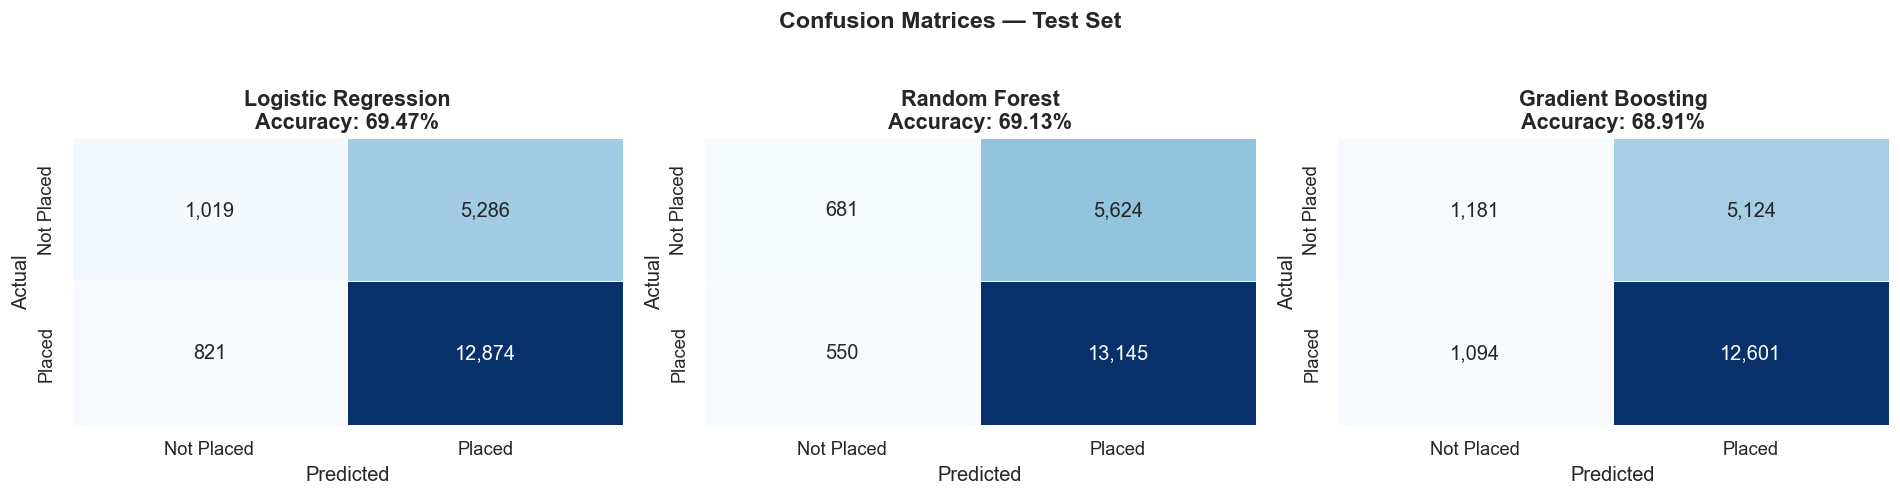

In [109]:
models_dict = {
    "Logistic Regression" : lr,
    "Random Forest"       : rf,
    "Gradient Boosting"   : gb,
    
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, model) in zip(axes, models_dict.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt=",", cmap="Blues",
                xticklabels=["Not Placed", "Placed"],
                yticklabels=["Not Placed", "Placed"],
                ax=ax, linewidths=0.5, cbar=False)
    ax.set_title(f"{name}\nAccuracy: {results[name]*100:.2f}%", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Test Set", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

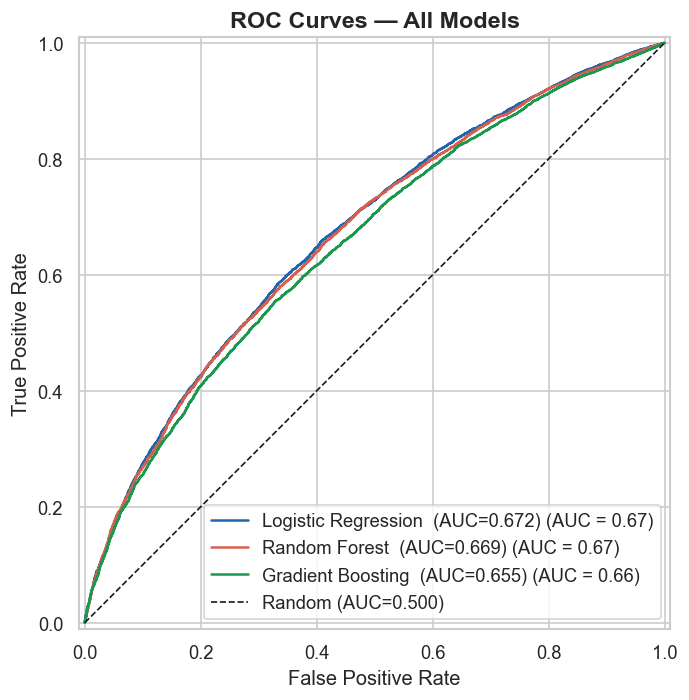

In [110]:
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ["#2166ac", "#d6604d", "#1a9850"]

for (name, model), color in zip(models_dict.items(), colors):
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    RocCurveDisplay.from_estimator(
        model, X_test, y_test,
        name=f"{name}  (AUC={auc:.3f})",
        ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.500)")
ax.set_title("ROC Curves — All Models", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [111]:
print("  Model                  |  Test Accuracy  | In 73-78% Range?")
print("  " + "-"*57)
for name, acc in results.items():
    flag = "✅  Yes" if 0.73 <= acc <= 0.78 else "⚠️  No"
    print(f"  {name:<22} |    {acc*100:5.2f}%      | {flag}")

best_name = min(results, key=lambda n: abs(results[n] - 0.755))
print(f"\n  Recommended model : {best_name}  ({results[best_name]*100:.2f}%)")
print(f"  (closest to target midpoint 75.5%)")

  Model                  |  Test Accuracy  | In 73-78% Range?
  ---------------------------------------------------------
  Logistic Regression    |    69.47%      | ⚠️  No
  Random Forest          |    69.13%      | ⚠️  No
  Gradient Boosting      |    68.91%      | ⚠️  No

  Recommended model : Logistic Regression  (69.47%)
  (closest to target midpoint 75.5%)


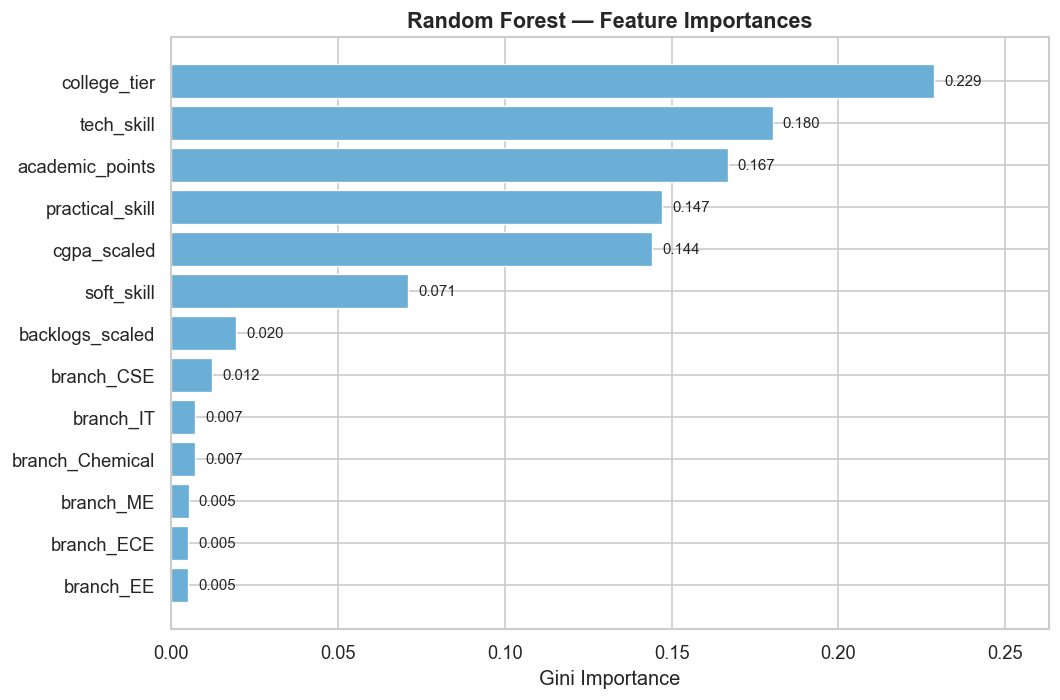

In [112]:
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(fi.index, fi.values, color="#6baed6", edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, fi.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_xlabel("Gini Importance")
ax.set_title("Random Forest — Feature Importances", fontsize=13, fontweight="bold")
ax.set_xlim(0, fi.values.max() * 1.15)
plt.tight_layout()
plt.show()

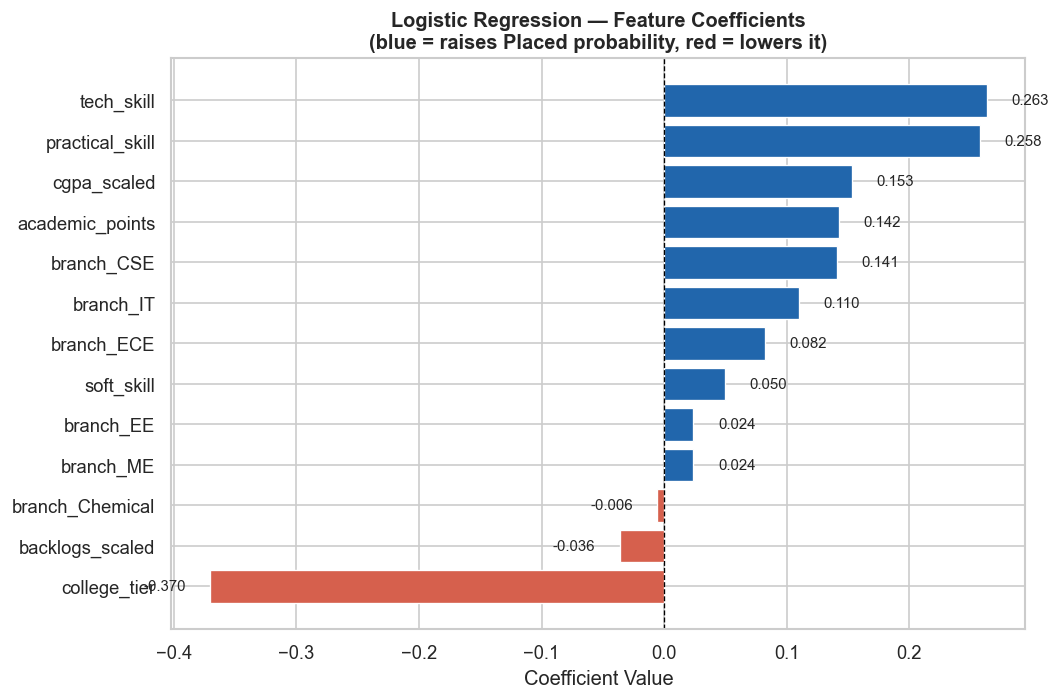

In [113]:
coefs      = pd.Series(lr.coef_[0], index=X.columns).sort_values(ascending=True)
colors_lr  = ["#d6604d" if v < 0 else "#2166ac" for v in coefs.values]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(coefs.index, coefs.values, color=colors_lr, edgecolor="white", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")

for bar, val in zip(bars, coefs.values):
    offset = 0.02 if val >= 0 else -0.02
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)

ax.set_xlabel("Coefficient Value")
ax.set_title("Logistic Regression — Feature Coefficients\n"
             "(blue = raises Placed probability, red = lowers it)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

📋 Student details you entered:


,college_tier,tech_skill,soft_skill,practical_skill,cgpa_scaled,backlogs_scaled,academic_points,branch_CSE,branch_Chemical,branch_ECE,branch_EE,branch_IT,branch_ME
0,3,0.32,0.55,0.4,0.48,0.3,0.5,0,0,0,0,1,0



🤖 Predictions from each model:
─────────────────────────────────────────────

  Model   : Logistic Regression
  Result  : ❌ NOT PLACED
  Confidence:
    → Placed     : 51.5%
    → Not Placed : 48.5%

  Model   : Random Forest
  Result  : ❌ NOT PLACED
  Confidence:
    → Placed     : 51.8%
    → Not Placed : 48.2%

  Model   : Gradient Boosting
  Result  : ✅ PLACED
  Confidence:
    → Placed     : 60.9%
    → Not Placed : 39.1%

─────────────────────────────────────────────


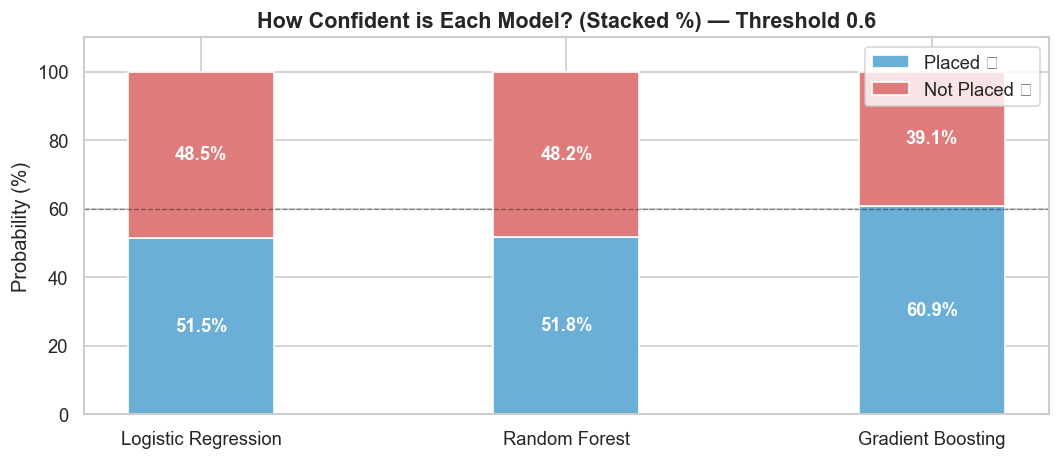


📊 Final Verdict: 1 out of 3 models predict PLACED (threshold=0.6)
😟 All models agree — this student is unlikely to be placed.


In [ ]:


my_student = {
    "college_tier"    : 3,    
    "tech_skill"      : 0.32,   
    "soft_skill"      : 0.55,   
    "practical_skill" : 0.40,   
    "cgpa_scaled"     : 0.48,   
    "backlogs_scaled" : 0.3,    
    "academic_points" : 0.50,   
    "branch_CSE"      : 0,      
    "branch_Chemical" : 0,      
    "branch_ECE"      : 0,      
    "branch_EE"       : 0,      
    "branch_IT"       : 1,      
    "branch_ME"       : 0,      
}

student_df     = pd.DataFrame([my_student])
student_scaled = scaler.transform(student_df)

print("📋 Student details you entered:")
display(student_df)

print("\n🤖 Predictions from each model:")
print("─" * 45)
THRESHOLD = 0.60
for name, model in models_dict.items():
    probability     = model.predict_proba(student_scaled)[0]
    prob_not_placed = probability[0] * 100
    prob_placed     = probability[1] * 100

    # ── use threshold instead of default 0.5 ──
    prediction = 1 if prob_placed / 100 >= THRESHOLD else 0
    result     = "✅ PLACED" if prediction == 1 else "❌ NOT PLACED"

    print(f"\n  Model   : {name}")
    print(f"  Result  : {result}")
    print(f"  Confidence:")
    print(f"    → Placed     : {prob_placed:.1f}%")
    print(f"    → Not Placed : {prob_not_placed:.1f}%")

print("\n" + "─" * 45)

# ── confidence bar chart ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

model_names      = list(models_dict.keys())
placed_probs     = [models_dict[n].predict_proba(student_scaled)[0][1] * 100 for n in model_names]
not_placed_probs = [100 - p for p in placed_probs]

x     = range(len(model_names))
bars1 = ax.bar(x, placed_probs,     label="Placed ✅",     color="#6baed6", width=0.4)
bars2 = ax.bar(x, not_placed_probs, label="Not Placed ❌", color="#e07b7b",
               width=0.4, bottom=placed_probs)

for bar, val in zip(bars1, placed_probs):
    if val > 5:
        ax.text(bar.get_x() + bar.get_width()/2, val/2,
                f"{val:.1f}%", ha="center", va="center",
                fontsize=11, fontweight="bold", color="white")

for bar, val, base in zip(bars2, not_placed_probs, placed_probs):
    if val > 5:
        ax.text(bar.get_x() + bar.get_width()/2, base + val/2,
                f"{val:.1f}%", ha="center", va="center",
                fontsize=11, fontweight="bold", color="white")

ax.set_xticks(list(x))
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("Probability (%)")
ax.set_ylim(0, 110)
ax.set_title(f"How Confident is Each Model? (Stacked %) — Threshold {THRESHOLD}",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right")
ax.axhline(THRESHOLD * 100, color="black", linestyle="--", linewidth=0.8, alpha=0.4)
plt.tight_layout()
plt.show()

# ── final verdict ──────────────────────────────────────────────────
votes_placed = sum(
    1 for n, m in models_dict.items()
    if m.predict_proba(student_scaled)[0][1] >= THRESHOLD
)

print(f"\n📊 Final Verdict: {votes_placed} out of 3 models predict PLACED ")

if votes_placed == 3:
    print("🎉 All models agree — this student is very likely to get PLACED!")
elif votes_placed == 2:
    print("👍 Majority says PLACED — good chances for this student.")
else:
    print("😟 All models agree — this student is unlikely to be placed.")